# Part 2: Feature Engineering & Modeling (Price Prediction)

Notebook này tiếp nối kết quả từ EDA Part 1. Chúng ta sẽ:
1. **Thực thi Task 12 (Sửa lỗi Price/Area)**: Sửa 8,146 lỗi `COMPOUND_UNIT_OLD_PARSER_WRONG`.
2. **Feature Engineering**: Tạo biến `price_per_m2`, mã hóa Quận/Phường.
3. **Modeling EDA**: Khảo sát phân bố của biến Target (`price_amount`).
4. **Train Model**: Xây dựng mô hình Machine Learning (LightGBM) để dự đoán giá.

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import setup_project_path

PROJECT_ROOT = setup_project_path()
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env", override=False)

from analytics.duckdb.connection import create_analytics_connection
from utils.price_area_validation import parse_price, parse_area, validate_price
from utils.address_parser import parse_address_text

print("Libraries loaded successfully.")

Đã phát hiện thư mục gốc của dự án RoomBeacon: /data/projects/roombeacon/source/roombeacon-system
Libraries loaded successfully.


## 1. Tải dữ liệu và Sửa lỗi Price (Thực thi Task 12)

In [3]:
conn = create_analytics_connection()

# Lấy dữ liệu với đầy đủ raw price và area từ v_observations thông qua JOIN
query = """
SELECT 
    p.rental_post_id, 
    p.source_code, 
    p.title_raw, 
    p.price_amount as old_price, 
    o.price_raw,
    p.area_value as old_area, 
    o.area_raw,
    p.best_address_text
FROM v_latest_posts p
JOIN v_observations o ON p.rental_post_id = o.rental_post_id
    AND p.latest_observed_at = o.observed_at
"""
df = conn.execute(query).df()
print(f"Loaded {len(df)} rows.")

Loaded 124916 rows.


In [4]:
# Áp dụng parser mới để FIX lỗi 8,146 COMPOUND_UNIT_OLD_PARSER_WRONG
df['fixed_price'] = df['price_raw'].apply(parse_price)
df['fixed_area'] = df['area_raw'].apply(parse_area)

# Chuyển đổi sang float để vẽ biểu đồ và train model
df['fixed_price'] = df['fixed_price'].astype(float)
df['fixed_area'] = df['fixed_area'].astype(float)

diff_count = (df['old_price'] != df['fixed_price']).sum()
print(f"Đã sửa {diff_count} giá trị Price bị lỗi từ parser cũ!")

Đã sửa 8634 giá trị Price bị lỗi từ parser cũ!


## 2. Lọc Dữ Liệu (Xóa Outlier & Missing Target)

In [5]:
# Chỉ lấy những tin có Giá hợp lệ (Target không bị None)
df_clean = df.dropna(subset=['fixed_price', 'fixed_area']).copy()

# Bỏ các giá trị dị thường (Ví dụ: giá < 500k hoặc > 500 triệu, diện tích < 5m2 hoặc > 1000m2)
df_clean = df_clean[
    (df_clean['fixed_price'] >= 500000) & (df_clean['fixed_price'] <= 500000000) &
    (df_clean['fixed_area'] >= 5) & (df_clean['fixed_area'] <= 1000)
]

# Tính giá trên mỗi m2
df_clean['price_per_m2'] = df_clean['fixed_price'] / df_clean['fixed_area']
print(f"Rows after cleaning outliers: {len(df_clean)}")

Rows after cleaning outliers: 122336


## 3. Khám phá Biến Mục Tiêu (Target EDA)

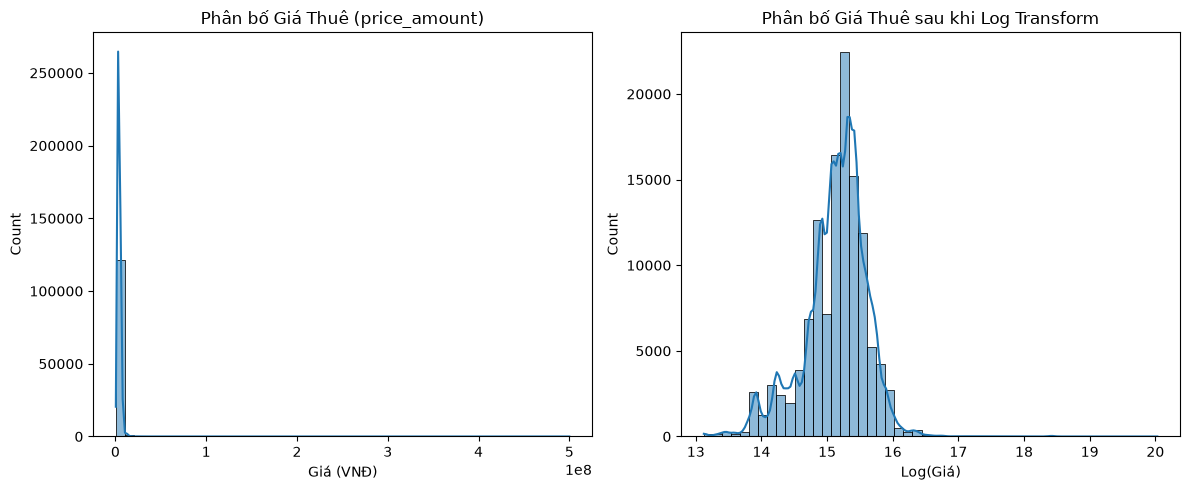

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['fixed_price'], bins=50, kde=True)
plt.title('Phân bố Giá Thuê (price_amount)')
plt.xlabel('Giá (VNĐ)')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_clean['fixed_price']), bins=50, kde=True)
plt.title('Phân bố Giá Thuê sau khi Log Transform')
plt.xlabel('Log(Giá)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering (Kỹ nghệ Đặc trưng)

In [7]:
# 4.1 Bóc tách Quận/Phường từ best_address_text
def extract_location(text):
    res = parse_address_text(str(text))
    if res['status'] == 'SUCCESS':
        return res['district_text_extracted'], res['ward_text_extracted']
    return None, None

df_clean[['district', 'ward']] = df_clean.apply(lambda row: pd.Series(extract_location(row['best_address_text'])), axis=1)

# 4.2 Loại hình BĐS từ title
def get_property_type(title):
    t = str(title).lower()
    if 'chung cư' in t or 'căn hộ' in t or 'apartment' in t:
        return 'apartment'
    if 'nhà nguyên căn' in t or 'cho thuê nhà' in t:
        return 'house'
    if 'mặt bằng' in t or 'shophouse' in t:
        return 'commercial'
    return 'room' # Default là phòng trọ

df_clean['property_type'] = df_clean['title_raw'].apply(get_property_type)

# Lấp đầy NaN categorical
df_clean['district'] = df_clean['district'].fillna('Unknown')
df_clean['ward'] = df_clean['ward'].fillna('Unknown')

KeyError: 'status'

## 5. Chọn "Máy" và Huấn luyện (LightGBM)

In [ ]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score

# Các Feature sử dụng
features = ['fixed_area', 'source_code', 'property_type', 'district', 'ward']
target = 'fixed_price'

X = df_clean[features].copy()
y = df_clean[target]

# Convert object columns to category for LightGBM
for c in ['source_code', 'property_type', 'district', 'ward']:
    X[c] = X[c].astype('category')

# Log transform target to handle skewness
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

print(f"R2 Score: {r2_score(y_test_real, y_pred):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_real, y_pred):,.0f} VNĐ")